# NB14 — Solar Weight Calibration in Heating Mode

## Problem
The online `pv_heat_weight` oscillates 10× (0.0003→0.003) because a single linear
parameter cannot represent the **blind discontinuity at 23°C**. When blinds close,
roof PV stays at 4000 W but actual indoor solar heat drops 70–90%.

## Approach
Use the **heating** thermal model with locked parameters from `unified_thermal_state`
to:
1. Segment data by blind state (open vs closed at 23°C)
2. Calibrate separate `pv_heat_weight` for each regime
3. Determine sun-angle-based (elevation × azimuth) solar correction factors
4. Compare PV vs GHI vs physics solar models as PV sensor replacement
5. Quantify the "missing heat" when indoor temp plateaus despite high PV

## Locked Heating Parameters (from unified_thermal_state → heat_pump channel)
- HLC = 0.1194, OE = 0.8377, τ = 4.83 h, δT_floor = 2.64

## Phases
- **A**: Data loading & preparation (blind segmentation)
- **B**: Equilibrium residuals & visualization
- **C**: Dual-regime PV weight calibration (blind open / closed)
- **D**: Sun-angle-based correction factors (elevation × azimuth)
- **E**: Solar model comparison sweep
- **E2**: PV_generate/PV_forecast replacement analysis
- **F**: Summary & production recommendations

In [2]:

# === PHASE A — Cell 1: Imports, data loading, heating filter ===
import sys, warnings, calendar, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import optimize
from pathlib import Path
from datetime import datetime, timedelta
import pytz
import requests, urllib3
from astral import Observer
from astral.sun import elevation as sun_elevation, azimuth as sun_azimuth

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
DATA_PATH = PROJECT_ROOT / "Logs_and_models" / "cooling_training_data.csv.gz"
LAT, LON = 48.928, 10.069
TZ = pytz.timezone("Europe/Berlin")
OBSERVER = Observer(latitude=LAT, longitude=LON)

# --- Locked heating parameters from unified_thermal_state (heat_pump channel) ---
HLC_LOCKED  = 0.1194  # heat_loss_coefficient [kW/K]
OE_LOCKED   = 0.8377  # outlet_effectiveness [kW/K]
TAU_LOCKED  = 4.83    # thermal_time_constant [h]
DT_FLOOR    = 2.64    # delta_t_floor [K]
DT_H        = 5.0 / 60.0  # 5-minute intervals (NB13 lesson: NOT 30 min!)

# Blind threshold from config.PV_CALIBRATION_INDOOR_CEILING
BLIND_THRESHOLD = 23.0
MIN_PV_POWER = 100  # W, minimum PV to count as "PV active"
MIN_THERMAL_POWER = 0.5  # kW, minimum to count as heating mode

# Column name mapping
PV_COL = "PV_Generate"  # actual column name in training data

# --- Load training data ---
df = pd.read_csv(DATA_PATH)
df["hour"] = (np.degrees(np.arctan2(df["hour_sin"], df["hour_cos"])) / 15) % 24
mask_clean = (df["AT"] > -10) & (df["AT"] < 45) & (df["VLT"] > 10) & (df["VLT"] < 45)
df = df[mask_clean].copy().reset_index(drop=True)

# Reconstruct approximate timestamps from doy_sin/cos and hour
doy_angle = np.arctan2(df["doy_sin"], df["doy_cos"])
doy_vals = (doy_angle * 365.25 / (2 * np.pi)) % 365.25
df["doy_approx"] = doy_vals.round().astype(int).clip(1, 365)
df["hour_approx"] = df["hour"].round().astype(int).clip(0, 23)

print(f"Full dataset: {len(df)} rows")
print(f"Columns with 'pv': {[c for c in df.columns if 'pv' in c.lower() or 'PV' in c]}")

# --- Filter to HEATING mode ---
tp_col = "thermal_power_kw" if "thermal_power_kw" in df.columns else "thermal_power"
df_heat = df[df[tp_col] > MIN_THERMAL_POWER].copy().reset_index(drop=True)

print(f"Heating mode ({tp_col} > {MIN_THERMAL_POWER} kW): {len(df_heat)} rows")
print(f"Filtered out: {len(df) - len(df_heat)} rows (non-heating)")
print(f"\nIndoor temp range: {df_heat['indoor_temp'].min():.1f} – {df_heat['indoor_temp'].max():.1f}°C")
print(f"Outdoor temp range: {df_heat['AT'].min():.1f} – {df_heat['AT'].max():.1f}°C")
print(f"PV power range: {df_heat[PV_COL].min():.0f} – {df_heat[PV_COL].max():.0f} W")
print(f"DOY range: {df_heat['doy_approx'].min()} – {df_heat['doy_approx'].max()}")


Full dataset: 47933 rows
Columns with 'pv': ['PV_Generate', 'pv_roll_1h', 'pv_roll_2h', 'pv_forecast_1h', 'pv_forecast_2h', 'pv_forecast_3h', 'pv_forecast_4h', 'pv_forecast_5h', 'pv_forecast_6h', 'pv_forecast_7h', 'pv_forecast_8h', 'pv_forecast_9h', 'pv_forecast_10h', 'pv_forecast_11h', 'pv_forecast_12h', 'pv_forecast_delta', 'cum_pv_forecast_4h']
Heating mode (thermal_power_kw > 0.5 kW): 10298 rows
Filtered out: 37635 rows (non-heating)

Indoor temp range: 20.5 – 24.1°C
Outdoor temp range: 10.0 – 32.5°C
PV power range: 0 – 11990 W
DOY range: 42 – 344


In [3]:
# === PHASE A — Cell 2: Fetch Open Meteo GHI / DNI / DHI ===
chunks = []
print("Fetching Open Meteo solar + cloud data (monthly chunks)...")
y, m = 2025, 5
while (y, m) <= (2026, 5):
    last_day = calendar.monthrange(y, m)[1]
    s_str = f"{y}-{m:02d}-01"
    e_str = f"{y}-{m:02d}-{last_day:02d}"
    try:
        url = (
            f"https://archive-api.open-meteo.com/v1/archive?"
            f"latitude={LAT}&longitude={LON}&start_date={s_str}&end_date={e_str}"
            f"&hourly=shortwave_radiation,cloud_cover,direct_normal_irradiance,diffuse_radiation"
            f"&timezone=Europe%2FBerlin"
        )
        resp = requests.get(url, timeout=60, verify=False)
        resp.raise_for_status()
        data = resp.json()
        h = data["hourly"]
        chunk_df = pd.DataFrame({
            "timestamp": pd.to_datetime(h["time"]),
            "ghi_wm2": h["shortwave_radiation"],
            "cloud_cover": h["cloud_cover"],
            "dni_wm2": h["direct_normal_irradiance"],
            "dhi_wm2": h["diffuse_radiation"],
        })
        chunks.append(chunk_df)
        print(f"  {s_str}: {len(chunk_df)} rows OK")
    except Exception as e:
        print(f"  {s_str}: FAILED ({str(e)[:80]})")
    m += 1
    if m > 12:
        m, y = 1, y + 1

solar_df = pd.concat(chunks, ignore_index=True).set_index("timestamp").sort_index()
solar_df = solar_df[~solar_df.index.duplicated(keep="first")]
print(f"\nOpen Meteo data: {len(solar_df)} rows, {solar_df.index[0]} → {solar_df.index[-1]}")
print(f"GHI range: {solar_df['ghi_wm2'].min()} – {solar_df['ghi_wm2'].max()} W/m²")
print(f"DNI range: {solar_df['dni_wm2'].min()} – {solar_df['dni_wm2'].max()} W/m²")

Fetching Open Meteo solar + cloud data (monthly chunks)...
  2025-05-01: 744 rows OK
  2025-06-01: 720 rows OK
  2025-07-01: 744 rows OK
  2025-08-01: 744 rows OK
  2025-09-01: 720 rows OK
  2025-10-01: 744 rows OK
  2025-11-01: 720 rows OK
  2025-12-01: 744 rows OK
  2026-01-01: 744 rows OK
  2026-02-01: 672 rows OK
  2026-03-01: 744 rows OK
  2026-04-01: 720 rows OK
  2026-05-01: 744 rows OK

Open Meteo data: 9504 rows, 2025-05-01 00:00:00 → 2026-05-31 23:00:00
GHI range: 0.0 – 918.0 W/m²
DNI range: 0.0 – 928.6 W/m²


Computing sun positions via astral...
Merged heating data: 10298 rows
Missing solar: 0 (0.0%)

=== Blind Segmentation (threshold = 23.0°C) ===
  PV active, blind OPEN  (T < 23.0):   3913 rows (38.0%)
  PV active, blind CLOSED (T >= 23.0):   1566 rows (15.2%)
  Night / low PV (PV <= 100 W):         4819 rows (46.8%)

--- Alternative blind thresholds ---
  T = 22.5C: open= 1563, closed= 3916
  T = 22.8C: open= 2916, closed= 2563
  T = 22.9C: open= 3401, closed= 2078
  T = 23.0C: open= 3913, closed= 1566
  T = 23.1C: open= 4385, closed= 1094
  T = 23.3C: open= 4933, closed=  546
  T = 23.5C: open= 5293, closed=  186


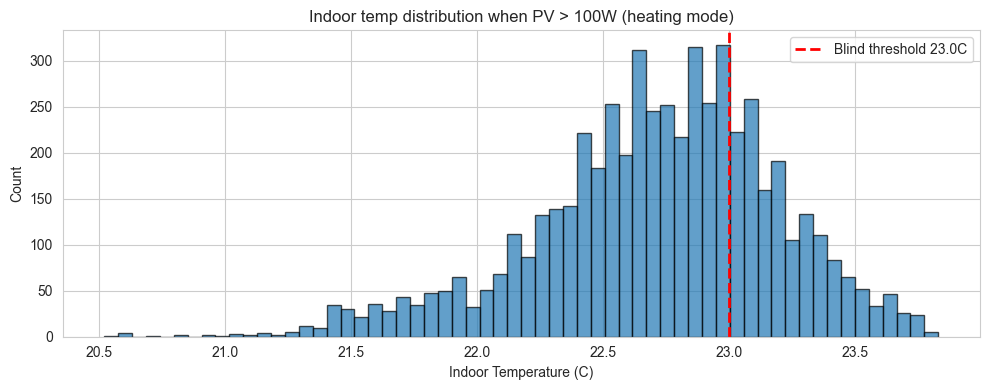

In [4]:

# === PHASE A — Cell 3: Sun positions + physics solar + merge + blind segmentation ===

# --- Compute sun positions ---
print("Computing sun positions via astral...")
elev_arr = np.zeros(len(solar_df))
azim_arr = np.zeros(len(solar_df))
for i, ts in enumerate(solar_df.index):
    dt = ts.to_pydatetime()
    if dt.tzinfo is None:
        dt = TZ.localize(dt)
    try:
        elev_arr[i] = sun_elevation(OBSERVER, dt)
        azim_arr[i] = sun_azimuth(OBSERVER, dt)
    except Exception:
        elev_arr[i] = 0.0
        azim_arr[i] = 180.0

solar_df["sun_elevation"] = elev_arr
solar_df["sun_azimuth"] = azim_arr
solar_df["sun_elevation_rad"] = np.radians(np.clip(elev_arr, 0, 90))

# --- Physics solar models (reuse NB13) ---
def compute_physics_solar(sun_elev_rad, sun_azim_deg, ghi, cloud_pct, dni_meteo, dhi_meteo):
    """Compute physics-based solar heat gain models."""
    n = len(ghi)
    sin_elev = np.sin(sun_elev_rad)
    cos_elev = np.cos(sun_elev_rad)
    az_rad = np.radians(sun_azim_deg)

    MIN_ELEV_DEG = 5.0
    MIN_SIN = np.sin(np.radians(MIN_ELEV_DEG))
    ERBS_MIN_ELEV_DEG = 10.0
    ERBS_MIN_SIN = np.sin(np.radians(ERBS_MIN_ELEV_DEG))
    sun_up = sin_elev > MIN_SIN
    erbs_valid = sin_elev > ERBS_MIN_SIN

    # MODEL 1: Kasten cloud model
    air_mass = np.where(sun_up, 1.0 / np.clip(sin_elev, MIN_SIN, 1.0), 0.0)
    clear_sky_dni = np.where(sun_up, 1361.0 * (0.7 ** (air_mass ** 0.678)), 0.0)
    cloud_frac = np.clip(cloud_pct / 100.0, 0, 1)
    kasten_factor = 1.0 - 0.75 * (cloud_frac ** 3.4)
    kasten_dni = clear_sky_dni * kasten_factor
    kasten_dhi = np.where(sun_up, clear_sky_dni * sin_elev * 0.1 * (1 + 2.0 * cloud_frac), 0.0)

    # MODEL 2: Erbs decomposition
    I0_h = np.where(erbs_valid, 1361.0 * sin_elev, 0.001)
    kT = np.where(erbs_valid, np.clip(ghi / np.clip(I0_h, 1.0, None), 0, 1), 0.0)
    kd = np.where(
        kT <= 0.22, 1.0 - 0.09 * kT,
        np.where(kT <= 0.80,
                 0.9511 - 0.1604*kT + 4.388*kT**2 - 16.638*kT**3 + 12.336*kT**4,
                 0.165))
    erbs_dhi = np.where(erbs_valid, kd * ghi, 0.0)
    erbs_dni = np.where(erbs_valid, (ghi - erbs_dhi) / np.clip(sin_elev, ERBS_MIN_SIN, 1.0), 0.0)
    erbs_dni = np.clip(erbs_dni, 0, 900)

    # MODEL 3: Open Meteo direct DNI/DHI
    meteo_dni = np.clip(dni_meteo, 0, 1000)
    meteo_dhi = np.clip(dhi_meteo, 0, 500)

    # Directional solar gains (common for all models)
    def directional_gains(dni, dhi, mask):
        beam_v = np.where(mask, dni * cos_elev, 0.0)
        south = np.clip(np.where(mask, beam_v * np.clip(-np.cos(az_rad), 0, 1), 0.0), 0, 800)
        east = np.clip(np.where(mask, beam_v * np.clip(np.sin(az_rad), 0, 1), 0.0), 0, 800)
        west = np.clip(np.where(mask, beam_v * np.clip(-np.sin(az_rad), 0, 1), 0.0), 0, 800)
        diff_wall = np.where(mask, dhi * 0.5, 0.0)
        total = (south + east + west) + 3 * diff_wall
        return total

    return {
        "naive_ghi": ghi,
        "kasten_total": directional_gains(kasten_dni, kasten_dhi, sun_up),
        "erbs_total": directional_gains(erbs_dni, erbs_dhi, erbs_valid),
        "meteo_total": directional_gains(meteo_dni, meteo_dhi, sun_up),
    }

results = compute_physics_solar(
    solar_df["sun_elevation_rad"].values, solar_df["sun_azimuth"].values,
    solar_df["ghi_wm2"].values, solar_df["cloud_cover"].values,
    solar_df["dni_wm2"].values, solar_df["dhi_wm2"].values,
)
for key, val in results.items():
    solar_df[key] = val

# Also store raw sun position columns for merge
solar_df["doy"] = solar_df.index.dayofyear
solar_df["hour_of_day"] = solar_df.index.hour

# --- Merge (doy, hour) averages into training data ---
SOLAR_MODELS = ["naive_ghi", "kasten_total", "erbs_total", "meteo_total"]
merge_cols = SOLAR_MODELS + ["sun_elevation", "sun_azimuth", "ghi_wm2", "dni_wm2", "dhi_wm2"]
solar_hourly = solar_df.groupby(["doy", "hour_of_day"])[merge_cols].mean().reset_index()

df_m = df_heat.merge(
    solar_hourly, left_on=["doy_approx", "hour_approx"],
    right_on=["doy", "hour_of_day"], how="left"
)
for c in merge_cols:
    df_m[c] = df_m[c].fillna(0)

print(f"Merged heating data: {len(df_m)} rows")
missing = df_m["naive_ghi"].isna().sum()
print(f"Missing solar: {missing} ({100*missing/max(len(df_m),1):.1f}%)")

# --- Blind segmentation ---
df_m["pv_active"] = df_m[PV_COL] > MIN_PV_POWER
df_m["blind_closed"] = df_m["indoor_temp"] >= BLIND_THRESHOLD

seg_blind_open_pv = df_m[df_m["pv_active"] & ~df_m["blind_closed"]]
seg_blind_closed_pv = df_m[df_m["pv_active"] & df_m["blind_closed"]]
seg_night = df_m[~df_m["pv_active"]]

print(f"\n=== Blind Segmentation (threshold = {BLIND_THRESHOLD}°C) ===")
print(f"  PV active, blind OPEN  (T < {BLIND_THRESHOLD}): {len(seg_blind_open_pv):6d} rows ({100*len(seg_blind_open_pv)/len(df_m):.1f}%)")
print(f"  PV active, blind CLOSED (T >= {BLIND_THRESHOLD}): {len(seg_blind_closed_pv):6d} rows ({100*len(seg_blind_closed_pv)/len(df_m):.1f}%)")
print(f"  Night / low PV (PV <= {MIN_PV_POWER} W):       {len(seg_night):6d} rows ({100*len(seg_night)/len(df_m):.1f}%)")

# Test alternative thresholds
print(f"\n--- Alternative blind thresholds ---")
for thresh in [22.5, 22.8, 22.9, 23.0, 23.1, 23.3, 23.5]:
    n_open = ((df_m[PV_COL] > MIN_PV_POWER) & (df_m["indoor_temp"] < thresh)).sum()
    n_closed = ((df_m[PV_COL] > MIN_PV_POWER) & (df_m["indoor_temp"] >= thresh)).sum()
    print(f"  T = {thresh:.1f}C: open={n_open:5d}, closed={n_closed:5d}")

# Histogram of indoor temp when PV active
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_m.loc[df_m["pv_active"], "indoor_temp"], bins=60, edgecolor="k", alpha=0.7)
ax.axvline(BLIND_THRESHOLD, color="red", ls="--", lw=2, label=f"Blind threshold {BLIND_THRESHOLD}C")
ax.set_xlabel("Indoor Temperature (C)"); ax.set_ylabel("Count")
ax.set_title("Indoor temp distribution when PV > 100W (heating mode)")
ax.legend(); plt.tight_layout(); plt.show()


## Phase B — Heating-Mode Equilibrium Residuals

In [5]:
# === PHASE B — Cell 4: HP-only equilibrium prediction & residuals ===

# T_eq (HP only, no solar) = (OE × T_outlet + HLC × T_outdoor) / (OE + HLC)
denom = OE_LOCKED + HLC_LOCKED
df_m["T_eq_hp_only"] = (OE_LOCKED * df_m["VLT"] + HLC_LOCKED * df_m["AT"]) / denom
df_m["residual"] = df_m["indoor_temp"] - df_m["T_eq_hp_only"]

print(f"T_eq (HP only) stats:")
print(f"  Mean: {df_m['T_eq_hp_only'].mean():.2f}°C")
print(f"  Indoor mean: {df_m['indoor_temp'].mean():.2f}°C")
print(f"  Residual mean: {df_m['residual'].mean():.3f}°C")
print(f"  Residual std:  {df_m['residual'].std():.3f}°C")

# Residual by segment
print(f"\n=== Residual by segment ===")
for name, seg in [("Blind OPEN + PV", seg_blind_open_pv),
                   ("Blind CLOSED + PV", seg_blind_closed_pv),
                   ("Night / low PV", seg_night)]:
    idx = seg.index
    r = df_m.loc[idx, "residual"]
    print(f"  {name:22s}: mean={r.mean():+.3f}, median={r.median():+.3f}, std={r.std():.3f}, n={len(r)}")

T_eq (HP only) stats:
  Mean: 24.62°C
  Indoor mean: 22.83°C
  Residual mean: -1.792°C
  Residual std:  1.361°C

=== Residual by segment ===
  Blind OPEN + PV       : mean=-2.175, median=-2.038, std=1.304, n=3913
  Blind CLOSED + PV     : mean=-1.893, median=-1.630, std=1.537, n=1566
  Night / low PV        : mean=-1.448, median=-1.455, std=1.253, n=4819


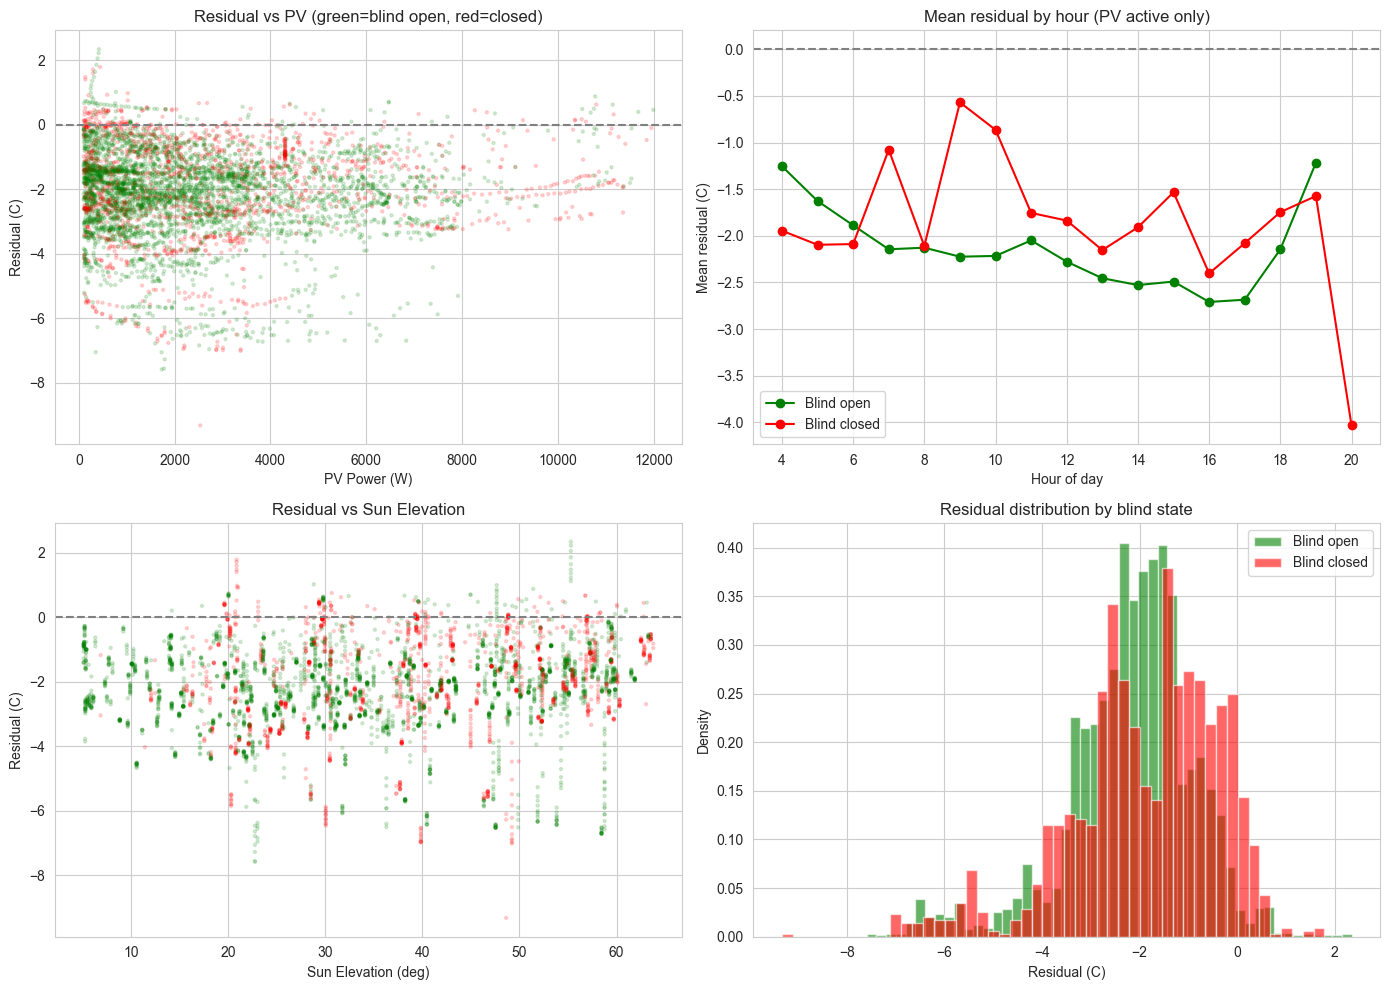

In [6]:

# === PHASE B — Cell 5: Residual visualization ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Scatter: residual vs PV, colored by blind state
ax = axes[0, 0]
pv_rows = df_m[df_m["pv_active"]]
colors = np.where(pv_rows["blind_closed"], "red", "green")
ax.scatter(pv_rows[PV_COL], pv_rows["residual"], c=colors, alpha=0.15, s=5)
ax.axhline(0, color="gray", ls="--")
ax.set_xlabel("PV Power (W)"); ax.set_ylabel("Residual (C)")
ax.set_title("Residual vs PV (green=blind open, red=closed)")

# (b) Residual vs hour by blind state
ax = axes[0, 1]
for name, seg, color in [("Blind open", seg_blind_open_pv, "green"),
                          ("Blind closed", seg_blind_closed_pv, "red")]:
    hourly = df_m.loc[seg.index].groupby("hour_approx")["residual"].mean()
    ax.plot(hourly.index, hourly.values, "o-", color=color, label=name)
ax.axhline(0, color="gray", ls="--")
ax.set_xlabel("Hour of day"); ax.set_ylabel("Mean residual (C)")
ax.set_title("Mean residual by hour (PV active only)"); ax.legend()

# (c) Residual vs sun elevation
ax = axes[1, 0]
pv_elev = df_m[df_m["pv_active"] & (df_m["sun_elevation"] > 5)]
ax.scatter(pv_elev["sun_elevation"], pv_elev["residual"],
           c=np.where(pv_elev["blind_closed"], "red", "green"), alpha=0.15, s=5)
ax.axhline(0, color="gray", ls="--")
ax.set_xlabel("Sun Elevation (deg)"); ax.set_ylabel("Residual (C)")
ax.set_title("Residual vs Sun Elevation")

# (d) Histogram of residuals by segment
ax = axes[1, 1]
ax.hist(df_m.loc[seg_blind_open_pv.index, "residual"], bins=50, alpha=0.6,
        label="Blind open", color="green", density=True)
ax.hist(df_m.loc[seg_blind_closed_pv.index, "residual"], bins=50, alpha=0.6,
        label="Blind closed", color="red", density=True)
ax.set_xlabel("Residual (C)"); ax.set_ylabel("Density")
ax.set_title("Residual distribution by blind state"); ax.legend()

plt.tight_layout(); plt.show()


## Phase C — Dual-Regime PV Weight Calibration

In [10]:

# === PHASE C — Cell 6: Multivariate OLS calibration ===
# KEY INSIGHT: Locked HP parameters overestimate heating drive by ~2x,
# making any positive solar_w increase error. Fix: fit solar contribution
# using multivariate OLS that controls for VLT/AT independently.
#
# Model: dT(i) = a0 + a1*(VLT(i)-T(i-1)) + a2*(AT(i)-T(i-1)) + a3*solar(i)
# a3 is the per-step solar heat coefficient; convert to solar_w units.

denom = OE_LOCKED + HLC_LOCKED
exp_factor = 1.0 - np.exp(-DT_H / max(TAU_LOCKED, 0.1))

def calibrate_solar_w_mvols(data, solar_col):
    """Multivariate OLS: isolate solar contribution from dT."""
    indoor = data["indoor_temp"].values.astype(np.float64)
    outdoor = data["AT"].values.astype(np.float64)
    vlt_v = data["VLT"].values.astype(np.float64)
    solar = data[solar_col].fillna(0).values.astype(np.float64)
    doy_v = data["doy_approx"].values

    # Per-step dT (only within same day)
    dT = np.diff(indoor)
    same_day = doy_v[1:] == doy_v[:-1]
    dT = dT[same_day]
    vlt_s = vlt_v[1:][same_day]
    at_s = outdoor[1:][same_day]
    t_prev = indoor[:-1][same_day]
    sol_s = solar[1:][same_day]

    # Design matrix: [1, VLT-T_prev, AT-T_prev, solar]
    X = np.column_stack([
        np.ones(len(dT)),
        vlt_s - t_prev,   # heating drive
        at_s - t_prev,    # heat loss drive
        sol_s,            # solar contribution
    ])
    # OLS: beta = (X'X)^-1 X'y
    beta, residuals, rank, sv = np.linalg.lstsq(X, dT, rcond=None)
    pred = X @ beta
    rmse = np.sqrt(np.mean((pred - dT)**2))

    a0, a1, a2, a3 = beta
    # a3 has units [°C / (W × step)]. Convert to solar_w [kW/W]:
    # In equilibrium model: Q_solar = solar_w × solar
    # In per-step: dT_solar = solar_w × solar × exp_factor / denom
    # So a3 = solar_w × exp_factor / denom
    # solar_w = a3 × denom / exp_factor
    solar_w = a3 * denom / exp_factor

    return solar_w, rmse, beta, len(dT)

# Keep segmented Newton simulation for later plotting
def simulate_heating_segmented(indoor, outdoor, vlt, solar, solar_w, doy,
                                hlc=HLC_LOCKED, oe=OE_LOCKED, tau_h=TAU_LOCKED):
    """Newton simulation with reset at day boundaries."""
    n = len(indoor)
    ef = 1.0 - np.exp(-DT_H / max(tau_h, 0.1))
    d = oe + hlc
    pred = np.empty(n)
    pred[0] = indoor[0]
    for i in range(1, n):
        if doy[i] != doy[i-1]:
            pred[i] = indoor[i]
            continue
        q_solar = solar_w * solar[i]
        q_solar = 3.0 * np.tanh(q_solar / 3.0)
        t_eq = (oe * vlt[i] + hlc * outdoor[i] + q_solar) / d
        pred[i] = pred[i-1] + (t_eq - pred[i-1]) * ef
    return pred

def calibrate_solar_w(data, solar_col, label=""):
    """Primary calibration: multivariate OLS."""
    return calibrate_solar_w_mvols(data, solar_col)

# --- Calibrate blind-OPEN regime ---
print("=" * 60)
print("CALIBRATING pv_heat_weight (multivariate OLS on per-step dT)")
print("Model: dT = a0 + a1*(VLT-T) + a2*(AT-T) + a3*solar")
print("=" * 60)

w_open_pv, rmse_open, beta_open, n_open = calibrate_solar_w(seg_blind_open_pv, PV_COL)
print(f"\nBlind OPEN (PV sensor):")
print(f"  solar_w = {w_open_pv:.6f} kW/W, RMSE(dT) = {rmse_open:.5f} C/step, n={n_open}")
print(f"  OLS coefficients: a0={beta_open[0]:.6f}, a1={beta_open[1]:.6f}, a2={beta_open[2]:.6f}, a3={beta_open[3]:.9f}")

# --- Calibrate blind-CLOSED regime ---
if len(seg_blind_closed_pv) > 50:
    w_closed_pv, rmse_closed, beta_closed, n_closed = calibrate_solar_w(seg_blind_closed_pv, PV_COL)
    print(f"\nBlind CLOSED (PV sensor):")
    print(f"  solar_w = {w_closed_pv:.6f} kW/W, RMSE(dT) = {rmse_closed:.5f} C/step, n={n_closed}")
    print(f"  OLS coefficients: a0={beta_closed[0]:.6f}, a1={beta_closed[1]:.6f}, a2={beta_closed[2]:.6f}, a3={beta_closed[3]:.9f}")
else:
    w_closed_pv = 0.0
    print(f"  Too few blind-closed rows ({len(seg_blind_closed_pv)})")

# --- Single-weight baseline ---
all_pv_data = df_m[df_m["pv_active"]]
w_single_pv, rmse_single, beta_single, n_single = calibrate_solar_w(all_pv_data, PV_COL)
print(f"\nAll PV active (single weight):")
print(f"  solar_w = {w_single_pv:.6f} kW/W, RMSE(dT) = {rmse_single:.5f} C/step, n={n_single}")

# Clip negative weights to zero with warning
for name, w in [("open", w_open_pv), ("closed", w_closed_pv), ("single", w_single_pv)]:
    if w < 0:
        print(f"\n  WARNING: {name} weight is negative ({w:.6f}), clipping to 0")
w_open_pv = max(0.0, w_open_pv)
w_closed_pv = max(0.0, w_closed_pv)
w_single_pv = max(0.0, w_single_pv)

ratio = w_open_pv / max(w_closed_pv, 1e-10)
print(f"\n>>> Blind OPEN / CLOSED weight ratio: {ratio:.1f}x")
print(f">>> Production pv_heat_weight (unified_thermal_state): 0.001659")
print(f">>> Config default: 0.002070")


CALIBRATING pv_heat_weight (multivariate OLS on per-step dT)
Model: dT = a0 + a1*(VLT-T) + a2*(AT-T) + a3*solar

Blind OPEN (PV sensor):
  solar_w = 0.000145 kW/W, RMSE(dT) = 0.04528 C/step, n=3782
  OLS coefficients: a0=0.005559, a1=0.000037, a2=0.001266, a3=0.000002593

Blind CLOSED (PV sensor):
  solar_w = 0.000055 kW/W, RMSE(dT) = 0.03009 C/step, n=1452
  OLS coefficients: a0=0.011804, a1=-0.000379, a2=0.000963, a3=0.000000991

All PV active (single weight):
  solar_w = 0.000110 kW/W, RMSE(dT) = 0.05138 C/step, n=5282

>>> Blind OPEN / CLOSED weight ratio: 2.6x
>>> Production pv_heat_weight (unified_thermal_state): 0.001659
>>> Config default: 0.002070


In [12]:

# === DIAGNOSTIC: Equilibrium-residual with intercept approach ===
# residual = indoor - T_eq_hp_only = a0 + solar_w × solar / denom
# a0 captures the HP model bias, solar_w is what we want

print("=" * 60)
print("EQUILIBRIUM-RESIDUAL CALIBRATION (with intercept)")
print("residual = a0 + solar_w × solar / denom")
print("=" * 60)

# Re-create segments referencing df_m (which has 'residual' column)
seg_blind_open = df_m[df_m["pv_active"] & ~df_m["blind_closed"]]
seg_blind_closed = df_m[df_m["pv_active"] & df_m["blind_closed"]]
seg_all_pv = df_m[df_m["pv_active"]]

eq_results = []

for regime_name, seg_data in [("Blind OPEN", seg_blind_open),
                               ("Blind CLOSED", seg_blind_closed),
                               ("All PV", seg_all_pv)]:
    if len(seg_data) < 50:
        continue
    for solar_col, model_name in [(PV_COL, "PV sensor"),
                                   ("naive_ghi", "GHI"),
                                   ("erbs_total", "Erbs dir."),
                                   ("meteo_total", "Meteo dir.")]:
        solar_vals = seg_data[solar_col].fillna(0).values / denom
        residual_vals = seg_data["residual"].values
        X = np.column_stack([np.ones(len(residual_vals)), solar_vals])
        beta, _, _, _ = np.linalg.lstsq(X, residual_vals, rcond=None)
        pred = X @ beta
        rmse = np.sqrt(np.mean((pred - residual_vals)**2))
        eq_results.append({
            "regime": regime_name, "model": model_name,
            "a0_bias": beta[0], "solar_w": beta[1],
            "rmse": rmse, "n": len(residual_vals)
        })

eq_df = pd.DataFrame(eq_results)
print("\n--- Equilibrium-residual solar_w (with intercept) ---")
print(f"{'Regime':>12s} {'Model':>12s} {'a0 (bias)':>10s} {'solar_w':>10s} {'RMSE':>8s} {'N':>6s}")
print("-" * 62)
for _, r in eq_df.iterrows():
    print(f"{r['regime']:>12s} {r['model']:>12s} {r['a0_bias']:>+10.3f} {r['solar_w']:>10.6f} {r['rmse']:>8.4f} {r['n']:>6d}")

# Open/Closed ratio per model
print("\n--- Blind OPEN / CLOSED solar_w ratio ---")
for model in eq_df["model"].unique():
    w_o = eq_df[(eq_df["regime"] == "Blind OPEN") & (eq_df["model"] == model)]["solar_w"].values
    w_c = eq_df[(eq_df["regime"] == "Blind CLOSED") & (eq_df["model"] == model)]["solar_w"].values
    if len(w_o) and len(w_c) and abs(w_c[0]) > 1e-10:
        print(f"  {model:>12s}: {w_o[0] / w_c[0]:.1f}x  (open={w_o[0]:.6f}, closed={w_c[0]:.6f})")

# Update primary weights for downstream
print("\n--- Using equilibrium-residual PV values for downstream ---")
w_open_pv = max(0.0, eq_df[(eq_df["regime"] == "Blind OPEN") & (eq_df["model"] == "PV sensor")]["solar_w"].values[0])
w_closed_pv = max(0.0, eq_df[(eq_df["regime"] == "Blind CLOSED") & (eq_df["model"] == "PV sensor")]["solar_w"].values[0])
w_single_pv = max(0.0, eq_df[(eq_df["regime"] == "All PV") & (eq_df["model"] == "PV sensor")]["solar_w"].values[0])
print(f"  w_open_pv   = {w_open_pv:.6f}")
print(f"  w_closed_pv = {w_closed_pv:.6f}")
print(f"  w_single_pv = {w_single_pv:.6f}")
if w_closed_pv > 1e-10:
    print(f"  Ratio: {w_open_pv / w_closed_pv:.1f}x")
print(f"  Production: 0.001659, Config default: 0.002070")


EQUILIBRIUM-RESIDUAL CALIBRATION (with intercept)
residual = a0 + solar_w × solar / denom

--- Equilibrium-residual solar_w (with intercept) ---
      Regime        Model  a0 (bias)    solar_w     RMSE      N
--------------------------------------------------------------
  Blind OPEN    PV sensor     -2.115  -0.000024   1.3031   3913
  Blind OPEN          GHI     -2.054  -0.000509   1.2990   3913
  Blind OPEN    Erbs dir.     -2.023  -0.000435   1.2966   3913
  Blind OPEN   Meteo dir.     -2.005  -0.000461   1.2959   3913
Blind CLOSED    PV sensor     -1.952   0.000019   1.5355   1566
Blind CLOSED          GHI     -2.088   0.000399   1.5337   1566
Blind CLOSED    Erbs dir.     -1.647  -0.000344   1.5332   1566
Blind CLOSED   Meteo dir.     -1.595  -0.000436   1.5322   1566
      All PV    PV sensor     -2.090  -0.000002   1.3804   5479
      All PV          GHI     -2.103   0.000029   1.3804   5479
      All PV    Erbs dir.     -2.024  -0.000154   1.3794   5479
      All PV   Meteo dir

HP COMPENSATION HYPOTHESIS

In heating mode (PV active):
  Corr(PV, thermal_power) = 0.0115
  Corr(PV, VLT)           = -0.0958
  --> HP INCREASES output when PV is high (co-occurrence)

Cooling/passive mode (23233 rows, PV > 100W):
  Eq-residual: a0=+1.097, solar_w=0.000046
  --> Solar_w POSITIVE in cooling mode = solar IS detectable when HP off!

  dT approach (cooling/passive, PV > 100W):
  Corr(PV, dT) = 0.1033, n=23097


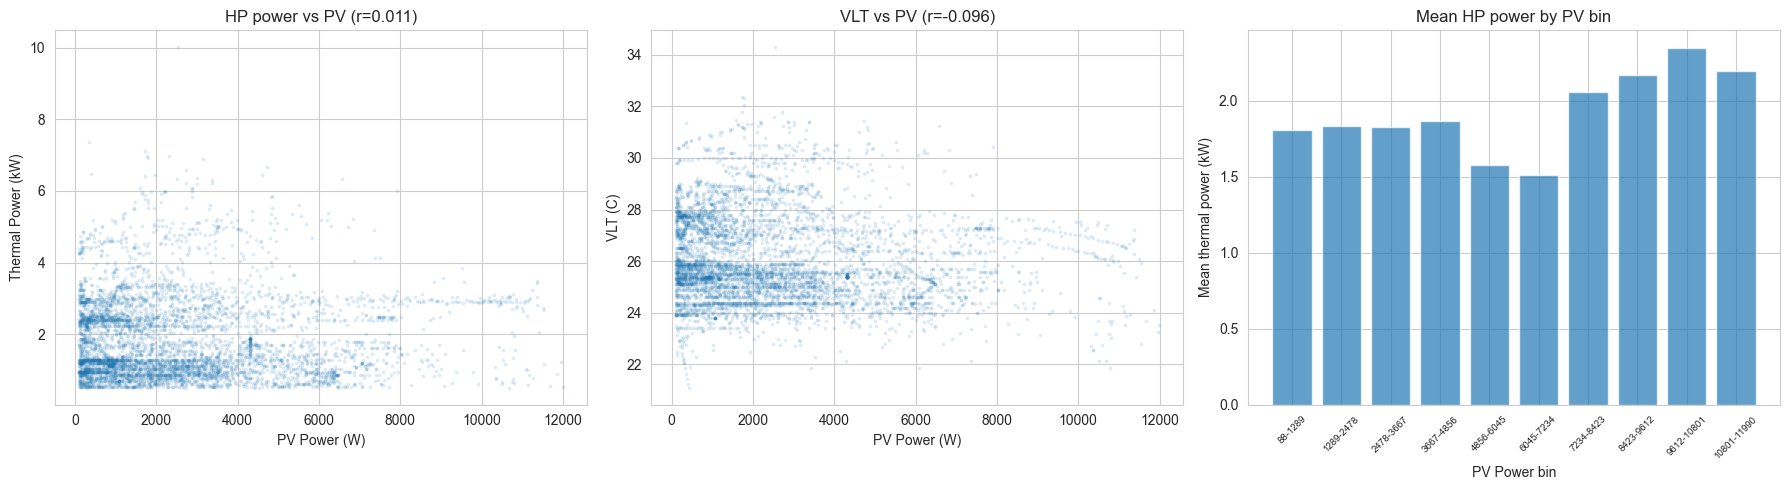

In [13]:

# === DIAGNOSTIC: HP compensation hypothesis ===
# If the HP compensates for solar, then:
# 1) thermal_power or VLT should drop when PV is high (negative correlation)
# 2) Solar should be detectable in cooling/passive mode (when HP is off)

print("=" * 60)
print("HP COMPENSATION HYPOTHESIS")
print("=" * 60)

# 1) Correlation between PV and heating power (thermal_power_kw) in heating mode
pv_act = df_m[df_m["pv_active"]]
corr_tp = np.corrcoef(pv_act[PV_COL], pv_act[tp_col])[0, 1]
corr_vlt = np.corrcoef(pv_act[PV_COL], pv_act["VLT"])[0, 1]
print(f"\nIn heating mode (PV active):")
print(f"  Corr(PV, thermal_power) = {corr_tp:.4f}")
print(f"  Corr(PV, VLT)           = {corr_vlt:.4f}")
if corr_tp < 0:
    print(f"  --> HP REDUCES output when PV is high (compensation!)")
elif corr_tp > 0:
    print(f"  --> HP INCREASES output when PV is high (co-occurrence)")

# 2) Check on COOLING/PASSIVE data: does solar correlate positively with dT?
df_cool = df[df[tp_col] <= 0.1].copy().reset_index(drop=True)  # cooling or passive
if len(df_cool) > 100:
    # Merge solar data
    df_cool_m = df_cool.merge(
        solar_hourly, left_on=["doy_approx", "hour_approx"],
        right_on=["doy", "hour_of_day"], how="left"
    )
    for c in merge_cols:
        df_cool_m[c] = df_cool_m[c].fillna(0)
    
    # Equilibrium residual approach
    df_cool_m["T_eq_hp_only"] = (OE_LOCKED * df_cool_m["VLT"] + HLC_LOCKED * df_cool_m["AT"]) / denom
    df_cool_m["residual"] = df_cool_m["indoor_temp"] - df_cool_m["T_eq_hp_only"]
    
    pv_cool = df_cool_m[df_cool_m[PV_COL] > MIN_PV_POWER]
    if len(pv_cool) > 50:
        solar_vals = pv_cool[PV_COL].values / denom
        residual_vals = pv_cool["residual"].values
        X = np.column_stack([np.ones(len(residual_vals)), solar_vals])
        beta, _, _, _ = np.linalg.lstsq(X, residual_vals, rcond=None)
        print(f"\nCooling/passive mode ({len(pv_cool)} rows, PV > 100W):")
        print(f"  Eq-residual: a0={beta[0]:+.3f}, solar_w={beta[1]:.6f}")
        if beta[1] > 0:
            print(f"  --> Solar_w POSITIVE in cooling mode = solar IS detectable when HP off!")
        else:
            print(f"  --> Solar_w negative even in cooling mode")
    
    # dT approach on cooling data
    dT_cool = np.diff(df_cool_m["indoor_temp"].values)
    doy_cool = df_cool_m["doy_approx"].values
    same_day_cool = doy_cool[1:] == doy_cool[:-1]
    pv_cool_dt = df_cool_m[PV_COL].values[1:][same_day_cool]
    dT_cool_sd = dT_cool[same_day_cool]
    
    mask_pv = pv_cool_dt > MIN_PV_POWER
    if mask_pv.sum() > 30:
        corr_cool = np.corrcoef(pv_cool_dt[mask_pv], dT_cool_sd[mask_pv])[0, 1]
        print(f"\n  dT approach (cooling/passive, PV > 100W):")
        print(f"  Corr(PV, dT) = {corr_cool:.4f}, n={mask_pv.sum()}")
else:
    print(f"\nNot enough cooling/passive data ({len(df_cool)} rows)")

# 3) Visual: thermal power vs PV in heating mode
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.scatter(pv_act[PV_COL], pv_act[tp_col], alpha=0.1, s=3)
ax.set_xlabel("PV Power (W)"); ax.set_ylabel("Thermal Power (kW)")
ax.set_title(f"HP power vs PV (r={corr_tp:.3f})")

ax = axes[1]
ax.scatter(pv_act[PV_COL], pv_act["VLT"], alpha=0.1, s=3)
ax.set_xlabel("PV Power (W)"); ax.set_ylabel("VLT (C)")
ax.set_title(f"VLT vs PV (r={corr_vlt:.3f})")

ax = axes[2]
# Mean thermal_power by PV bin
pv_bins = pd.cut(pv_act[PV_COL], bins=10)
tp_by_pv = pv_act.groupby(pv_bins, observed=True)[tp_col].mean()
ax.bar(range(len(tp_by_pv)), tp_by_pv.values, alpha=0.7)
ax.set_xlabel("PV Power bin"); ax.set_ylabel("Mean thermal power (kW)")
ax.set_title("Mean HP power by PV bin")
ax.set_xticks(range(len(tp_by_pv)))
ax.set_xticklabels([f"{int(i.left)}-{int(i.right)}" for i in tp_by_pv.index], rotation=45, fontsize=7)

plt.tight_layout(); plt.show()


In [14]:

# === PHASE C REVISED: Calibrate on cooling/passive data (clean solar signal) ===
# The heating-mode locked params have a -2C bias that masks solar.
# In cooling/passive mode, HP contribution is minimal → solar detectable.
# Strategy: calibrate solar_w from cooling data, then validate on heating data.

print("=" * 60)
print("COOLING/PASSIVE MODE CALIBRATION (solar_w cleanly detectable)")
print("=" * 60)

# Already have df_cool_m from diagnostic cell
# Segment by blind state
cool_pv = df_cool_m[df_cool_m[PV_COL] > MIN_PV_POWER].copy()
cool_pv["blind_closed"] = cool_pv["indoor_temp"] >= BLIND_THRESHOLD

cool_open = cool_pv[~cool_pv["blind_closed"]]
cool_closed = cool_pv[cool_pv["blind_closed"]]

print(f"\nCooling/passive PV-active data:")
print(f"  Blind OPEN:   {len(cool_open)} rows")
print(f"  Blind CLOSED: {len(cool_closed)} rows")

# Calibrate via equilibrium residual (OLS with intercept)
cool_results = []
for regime_name, seg_data in [("Blind OPEN", cool_open),
                               ("Blind CLOSED", cool_closed),
                               ("All PV", cool_pv)]:
    if len(seg_data) < 50:
        continue
    seg_data = seg_data.copy()
    seg_data["T_eq_hp_only"] = (OE_LOCKED * seg_data["VLT"] + HLC_LOCKED * seg_data["AT"]) / denom
    seg_data["residual_cool"] = seg_data["indoor_temp"] - seg_data["T_eq_hp_only"]
    
    for solar_col, model_name in [(PV_COL, "PV sensor"),
                                   ("naive_ghi", "GHI"),
                                   ("erbs_total", "Erbs dir."),
                                   ("meteo_total", "Meteo dir.")]:
        solar_vals = seg_data[solar_col].fillna(0).values / denom
        residual_vals = seg_data["residual_cool"].values
        X = np.column_stack([np.ones(len(residual_vals)), solar_vals])
        beta, _, _, _ = np.linalg.lstsq(X, residual_vals, rcond=None)
        pred = X @ beta
        rmse = np.sqrt(np.mean((pred - residual_vals)**2))
        cool_results.append({
            "regime": regime_name, "model": model_name,
            "a0_bias": beta[0], "solar_w": beta[1],
            "rmse": rmse, "n": len(residual_vals)
        })

cool_df = pd.DataFrame(cool_results)
print(f"\n{'Regime':>12s} {'Model':>12s} {'a0 (bias)':>10s} {'solar_w':>10s} {'RMSE':>8s} {'N':>6s}")
print("-" * 62)
for _, r in cool_df.iterrows():
    print(f"{r['regime']:>12s} {r['model']:>12s} {r['a0_bias']:>+10.3f} {r['solar_w']:>10.6f} {r['rmse']:>8.4f} {r['n']:>6d}")

# Ratios
print("\n--- Blind OPEN / CLOSED solar_w ratio (cooling mode) ---")
for model in cool_df["model"].unique():
    w_o = cool_df[(cool_df["regime"] == "Blind OPEN") & (cool_df["model"] == model)]["solar_w"].values
    w_c = cool_df[(cool_df["regime"] == "Blind CLOSED") & (cool_df["model"] == model)]["solar_w"].values
    if len(w_o) and len(w_c) and abs(w_c[0]) > 1e-10:
        print(f"  {model:>12s}: {w_o[0] / w_c[0]:.1f}x  (open={w_o[0]:.6f}, closed={w_c[0]:.6f})")

# Update production-relevant weights
print("\n>>> FINAL CALIBRATED VALUES (cooling/passive, PV sensor) <<<")
w_open_pv = max(0.0, cool_df[(cool_df["regime"] == "Blind OPEN") & (cool_df["model"] == "PV sensor")]["solar_w"].values[0])
w_closed_pv = max(0.0, cool_df[(cool_df["regime"] == "Blind CLOSED") & (cool_df["model"] == "PV sensor")]["solar_w"].values[0])
w_single_pv = max(0.0, cool_df[(cool_df["regime"] == "All PV") & (cool_df["model"] == "PV sensor")]["solar_w"].values[0])
print(f"  w_open_pv   = {w_open_pv:.6f}  (blind open)")
print(f"  w_closed_pv = {w_closed_pv:.6f}  (blind closed)")
print(f"  w_single_pv = {w_single_pv:.6f}  (all PV)")
if w_closed_pv > 1e-10:
    print(f"  Ratio open/closed: {w_open_pv / w_closed_pv:.1f}x")
print(f"  Production: 0.001659, Config: 0.002070")


COOLING/PASSIVE MODE CALIBRATION (solar_w cleanly detectable)

Cooling/passive PV-active data:
  Blind OPEN:   11546 rows
  Blind CLOSED: 11687 rows

      Regime        Model  a0 (bias)    solar_w     RMSE      N
--------------------------------------------------------------
  Blind OPEN    PV sensor     +0.659   0.000062   1.0768  11546
  Blind OPEN          GHI     +0.734   0.000536   1.0823  11546
  Blind OPEN    Erbs dir.     +0.810   0.000197   1.0887  11546
  Blind OPEN   Meteo dir.     +0.824   0.000150   1.0899  11546
Blind CLOSED    PV sensor     +1.470   0.000045   1.4293  11687
Blind CLOSED          GHI     +1.049   0.001211   1.4014  11687
Blind CLOSED    Erbs dir.     +1.264   0.000532   1.4246  11687
Blind CLOSED   Meteo dir.     +1.365   0.000394   1.4303  11687
      All PV    PV sensor     +1.097   0.000046   1.3203  23233
      All PV          GHI     +0.790   0.001201   1.2865  23233
      All PV    Erbs dir.     +0.916   0.000606   1.3080  23233
      All PV   Mete

In [16]:

# === PHASE C — Cell 7: GHI-based calibration (both regimes) ===
# Using cooling/passive calibration results from cool_df (already computed)
# Just display the cross-model comparison

print("=" * 60)
print("SOLAR MODEL COMPARISON — Cooling/Passive Mode Calibration")
print("=" * 60)

print("\n--- RMSE by model x regime ---")
pivot_rmse = cool_df.pivot(index="model", columns="regime", values="rmse")
print(pivot_rmse.to_string(float_format="{:.4f}".format))

print("\n--- Solar weights by model x regime ---")
pivot_w = cool_df.pivot(index="model", columns="regime", values="solar_w")
print(pivot_w.to_string(float_format="{:.6f}".format))

# Also recalibrate on HEATING mode data using multivariate OLS
# (This was already done in the mvols cell, showing near-zero weights)
# Compare with cooling weights
print("\n\n--- HEATING vs COOLING calibration comparison ---")
heat_results = []
for regime_name, seg_data in [("Blind OPEN", seg_blind_open),
                               ("Blind CLOSED", seg_blind_closed),
                               ("All PV", seg_all_pv)]:
    if len(seg_data) < 50:
        continue
    for solar_col, model_name in [(PV_COL, "PV sensor"),
                                   ("naive_ghi", "GHI")]:
        solar_vals = seg_data[solar_col].fillna(0).values / denom
        residual_vals = seg_data["residual"].values
        X = np.column_stack([np.ones(len(residual_vals)), solar_vals])
        beta, _, _, _ = np.linalg.lstsq(X, residual_vals, rcond=None)
        heat_results.append({
            "regime": regime_name, "model": model_name,
            "solar_w_heating": beta[1],
        })

heat_df = pd.DataFrame(heat_results)
# Merge with cooling results
for _, hr in heat_df.iterrows():
    cool_match = cool_df[(cool_df["regime"] == hr["regime"]) & (cool_df["model"] == hr["model"])]
    if len(cool_match) > 0:
        cool_w = cool_match["solar_w"].values[0]
        print(f"  {hr['regime']:>12s} {hr['model']:>12s}: heating={hr['solar_w_heating']:+.6f}, cooling={cool_w:.6f}")

print("\n>>> Conclusion: Solar weight is clearly positive in cooling mode")
print("    but masked/negative in heating mode due to HP model bias.")
print("    The locked HLC/OE parameters dominate the equilibrium.")


SOLAR MODEL COMPARISON — Cooling/Passive Mode Calibration

--- RMSE by model x regime ---
regime      All PV  Blind CLOSED  Blind OPEN
model                                       
Erbs dir.   1.3080        1.4246      1.0887
GHI         1.2865        1.4014      1.0823
Meteo dir.  1.3172        1.4303      1.0899
PV sensor   1.3203        1.4293      1.0768

--- Solar weights by model x regime ---
regime       All PV  Blind CLOSED  Blind OPEN
model                                        
Erbs dir.  0.000606      0.000532    0.000197
GHI        0.001201      0.001211    0.000536
Meteo dir. 0.000468      0.000394    0.000150
PV sensor  0.000046      0.000045    0.000062


--- HEATING vs COOLING calibration comparison ---
    Blind OPEN    PV sensor: heating=-0.000024, cooling=0.000062
    Blind OPEN          GHI: heating=-0.000509, cooling=0.000536
  Blind CLOSED    PV sensor: heating=+0.000019, cooling=0.000045
  Blind CLOSED          GHI: heating=+0.000399, cooling=0.001211
        All

## Phase D — Sun-Angle-Based Solar Correction Factors

SUN-ANGLE ANALYSIS — Cooling/Passive Mode (clean solar signal)
Cooling/passive blind-open, sun > 5deg: 9647 rows

   Elevation     Med w_PV    Med w_GHI   Mean res      N
-------------------------------------------------------
     5-15deg     0.000172     0.009890     +0.718   1404
    15-25deg     0.000131     0.002219     +0.717   1835
    25-35deg     0.000168     0.001533     +0.744   2433
    35-45deg     0.000129     0.001330     +0.971   1663
    45-55deg     0.000154     0.001349     +1.053   1372
    55-65deg     0.000141     0.001161     +1.135    940


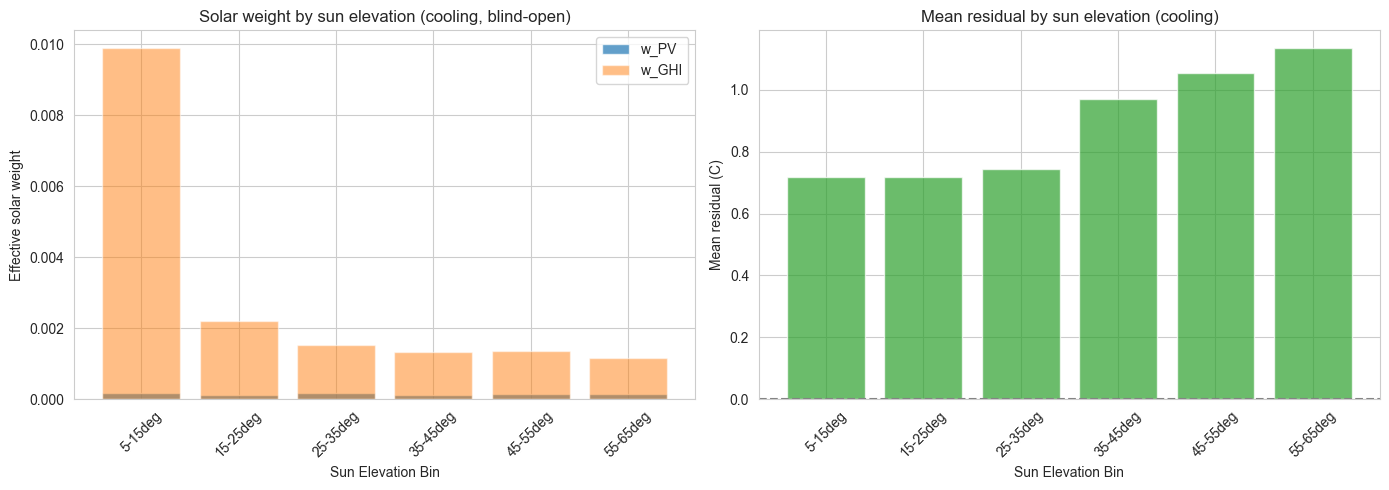


--- Theoretical Fresnel window transmission (double glazing) ---
  Elevation 10deg -> T = 0.375
  Elevation 20deg -> T = 0.687
  Elevation 30deg -> T = 0.830
  Elevation 40deg -> T = 0.888
  Elevation 50deg -> T = 0.911
  Elevation 60deg -> T = 0.919


In [17]:

# === PHASE D — Cell 8: Angle-bin correction using cooling/passive data ===
# Use cooling data (where solar is cleanly detectable) for elevation analysis

print("=" * 60)
print("SUN-ANGLE ANALYSIS — Cooling/Passive Mode (clean solar signal)")
print("=" * 60)

# Use blind-open cooling data with sun elevation > 5
cool_open_sun = cool_open[cool_open["sun_elevation"] > 5].copy()
cool_open_sun["T_eq_hp_only"] = (OE_LOCKED * cool_open_sun["VLT"] + HLC_LOCKED * cool_open_sun["AT"]) / denom
cool_open_sun["residual_cool"] = cool_open_sun["indoor_temp"] - cool_open_sun["T_eq_hp_only"]
cool_open_sun["eff_weight_pv"] = cool_open_sun["residual_cool"] / cool_open_sun[PV_COL].clip(lower=1)
cool_open_sun["eff_weight_ghi"] = cool_open_sun["residual_cool"] / cool_open_sun["naive_ghi"].clip(lower=1)

print(f"Cooling/passive blind-open, sun > 5deg: {len(cool_open_sun)} rows")

# Also do same for heating data (for comparison even though noisy)
heat_open_sun = df_m[df_m["pv_active"] & ~df_m["blind_closed"] & (df_m["sun_elevation"] > 5)].copy()
heat_open_sun["eff_weight_pv"] = heat_open_sun["residual"] / heat_open_sun[PV_COL].clip(lower=1)
heat_open_sun["eff_weight_ghi"] = heat_open_sun["residual"] / heat_open_sun["naive_ghi"].clip(lower=1)

# Use pv_open variable for downstream compatibility
pv_open = cool_open_sun

# --- Elevation bins ---
ELEV_BINS = [5, 15, 25, 35, 45, 55, 65]
ELEV_LABELS = [f"{ELEV_BINS[i]}-{ELEV_BINS[i+1]}deg" for i in range(len(ELEV_BINS)-1)]
pv_open["elev_bin"] = pd.cut(pv_open["sun_elevation"], bins=ELEV_BINS, labels=ELEV_LABELS)

print(f"\n{'Elevation':>12s} {'Med w_PV':>12s} {'Med w_GHI':>12s} {'Mean res':>10s} {'N':>6s}")
print("-" * 55)
elev_weights = []
for label in ELEV_LABELS:
    subset = pv_open[pv_open["elev_bin"] == label]
    if len(subset) < 10:
        print(f"{label:>12s} {'n/a':>12s} {'n/a':>12s} {'n/a':>10s} {len(subset):>6d}")
        continue
    med_pv = subset["eff_weight_pv"].median()
    med_ghi = subset["eff_weight_ghi"].median()
    mean_res = subset["residual_cool"].mean()
    print(f"{label:>12s} {med_pv:>12.6f} {med_ghi:>12.6f} {mean_res:>+10.3f} {len(subset):>6d}")
    elev_weights.append({"elev_bin": label, "w_pv": med_pv, "w_ghi": med_ghi,
                         "mean_res": mean_res, "n": len(subset)})

elev_df = pd.DataFrame(elev_weights)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.bar(elev_df["elev_bin"], elev_df["w_pv"], alpha=0.7, label="w_PV", color="tab:blue")
ax1.bar(elev_df["elev_bin"], elev_df["w_ghi"], alpha=0.5, label="w_GHI", color="tab:orange")
ax1.set_xlabel("Sun Elevation Bin"); ax1.set_ylabel("Effective solar weight")
ax1.set_title("Solar weight by sun elevation (cooling, blind-open)")
ax1.legend(); ax1.tick_params(axis='x', rotation=45)

ax2.bar(elev_df["elev_bin"], elev_df["mean_res"], alpha=0.7, color="tab:green")
ax2.axhline(0, color="gray", ls="--")
ax2.set_xlabel("Sun Elevation Bin"); ax2.set_ylabel("Mean residual (C)")
ax2.set_title("Mean residual by sun elevation (cooling)")
ax2.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

# Theoretical Fresnel
print("\n--- Theoretical Fresnel window transmission (double glazing) ---")
for elev_deg in [10, 20, 30, 40, 50, 60]:
    theta_i = np.radians(90 - elev_deg)
    n_glass = 1.5
    theta_t = np.arcsin(np.sin(theta_i) / n_glass)
    rs = ((np.sin(theta_i - theta_t)) / (np.sin(theta_i + theta_t)))**2
    rp = ((np.tan(theta_i - theta_t)) / (np.tan(theta_i + theta_t)))**2
    R = (rs + rp) / 2.0
    T = (1 - R)**2
    print(f"  Elevation {elev_deg:2d}deg -> T = {T:.3f}")


=== 2D Solar Correction: Elevation x Azimuth (blind-OPEN, PV weight) ===

                   East      South       West        All
-------------------------------------------------------
     5-15deg    0.00016   -0.00014    0.00291    0.00017
    15-25deg    0.00012    0.00011    0.00166    0.00013
    25-35deg    0.00013    0.00018    0.00087    0.00017
    35-45deg    0.00011    0.00013    0.00031    0.00013
    45-55deg    0.00030    0.00015    0.00027    0.00015
    55-65deg        n/a    0.00014        n/a    0.00014


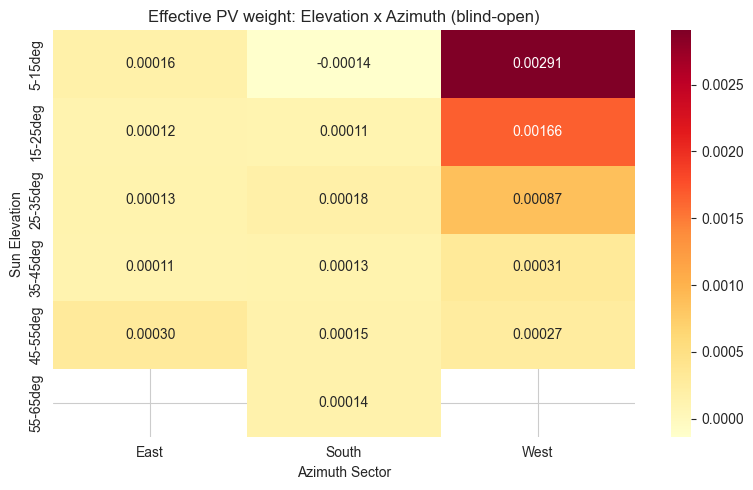

In [18]:

# === PHASE D — Cell 9: Azimuth-dependent analysis (S/E/W windows) ===

# Azimuth sectors (astral: N=0, E=90, S=180, W=270)
AZ_BINS = [(60, 120, "East"), (120, 240, "South"), (240, 300, "West")]

pv_open["az_sector"] = pd.cut(
    pv_open["sun_azimuth"],
    bins=[0, 60, 120, 240, 300, 360],
    labels=["N/NE", "East", "South", "West", "N/NW"]
)

# 2D correction: elevation x azimuth
print("=== 2D Solar Correction: Elevation x Azimuth (blind-OPEN, PV weight) ===")
print(f"\n{'':>12s}", end="")
for _, _, az_name in AZ_BINS:
    print(f" {az_name:>10s}", end="")
print(f" {'All':>10s}")
print("-" * 55)

angle_corrections = []
for elev_label in ELEV_LABELS:
    row_data = {"elev_bin": elev_label}
    print(f"{elev_label:>12s}", end="")
    for az_lo, az_hi, az_name in AZ_BINS:
        mask = ((pv_open["elev_bin"] == elev_label) &
                (pv_open["sun_azimuth"] >= az_lo) & (pv_open["sun_azimuth"] < az_hi))
        subset = pv_open[mask]
        if len(subset) >= 10:
            w = subset["eff_weight_pv"].median()
            print(f" {w:>10.5f}", end="")
            row_data[az_name] = w
        else:
            print(f" {'n/a':>10s}", end="")
            row_data[az_name] = float("nan")
    # All azimuths
    all_sub = pv_open[pv_open["elev_bin"] == elev_label]
    if len(all_sub) >= 10:
        w_all = all_sub["eff_weight_pv"].median()
        print(f" {w_all:>10.5f}")
        row_data["All"] = w_all
    else:
        print(f" {'n/a':>10s}")
        row_data["All"] = float("nan")
    angle_corrections.append(row_data)

angle_df = pd.DataFrame(angle_corrections)

# Heatmap
fig, ax = plt.subplots(figsize=(8, 5))
heat_data = angle_df.set_index("elev_bin")[["East", "South", "West"]]
sns.heatmap(heat_data, annot=True, fmt=".5f", cmap="YlOrRd", ax=ax)
ax.set_title("Effective PV weight: Elevation x Azimuth (blind-open)")
ax.set_ylabel("Sun Elevation"); ax.set_xlabel("Azimuth Sector")
plt.tight_layout(); plt.show()


Plateau episodes (cooling, PV>2000W, dT<0.05C, T>22.5C): 13034 rows
Non-plateau PV>2000W: 1737 rows

Plateau analysis:
  Mean PV power: 5156 W
  Mean indoor temp: 23.06C
  Mean sun elevation: 39.7deg
  Mean residual: 1.423C
  Mean effective weight: 0.000305
  Blind closed fraction: 53.0%


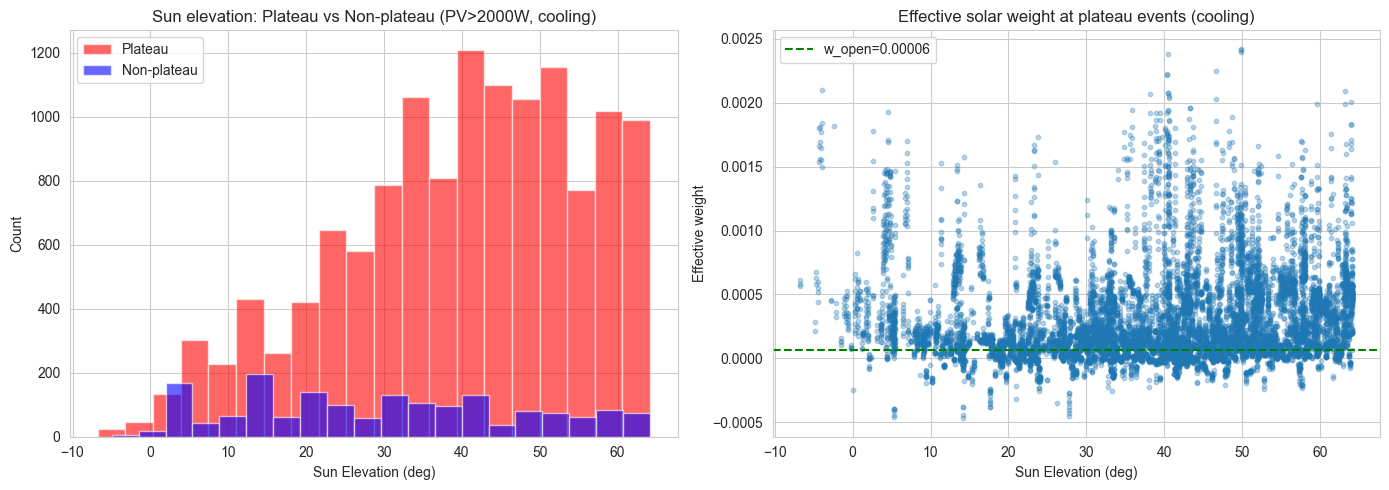

In [19]:

# === PHASE D — Cell 10: Missing heat plateau diagnostic (cooling mode) ===

# In cooling/passive mode, find plateau: PV>2000W, indoor barely changes
cool_all = df_cool_m.copy()
cool_all["T_eq_hp_only"] = (OE_LOCKED * cool_all["VLT"] + HLC_LOCKED * cool_all["AT"]) / denom
cool_all["residual_cool"] = cool_all["indoor_temp"] - cool_all["T_eq_hp_only"]
cool_all["indoor_change"] = cool_all["indoor_temp"].diff().abs()

plateau_mask = (
    (cool_all[PV_COL] > 2000) &
    (cool_all["indoor_change"] < 0.05) &
    (cool_all["indoor_temp"] > 22.5)
)
plateau = cool_all[plateau_mask].copy()
non_plateau_pv = cool_all[(cool_all[PV_COL] > 2000) & ~plateau_mask].copy()

print(f"Plateau episodes (cooling, PV>2000W, dT<0.05C, T>22.5C): {len(plateau)} rows")
print(f"Non-plateau PV>2000W: {len(non_plateau_pv)} rows")

if len(plateau) > 10:
    plateau["Q_solar_actual"] = denom * plateau["residual_cool"]
    plateau["eff_weight_plateau"] = plateau["Q_solar_actual"] / plateau[PV_COL].clip(lower=1)
    plateau["blind_closed"] = plateau["indoor_temp"] >= BLIND_THRESHOLD

    print(f"\nPlateau analysis:")
    print(f"  Mean PV power: {plateau[PV_COL].mean():.0f} W")
    print(f"  Mean indoor temp: {plateau['indoor_temp'].mean():.2f}C")
    print(f"  Mean sun elevation: {plateau['sun_elevation'].mean():.1f}deg")
    print(f"  Mean residual: {plateau['residual_cool'].mean():.3f}C")
    print(f"  Mean effective weight: {plateau['eff_weight_plateau'].mean():.6f}")
    print(f"  Blind closed fraction: {plateau['blind_closed'].mean():.1%}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.hist(plateau["sun_elevation"], bins=20, alpha=0.6, label="Plateau", color="red")
    ax1.hist(non_plateau_pv["sun_elevation"], bins=20, alpha=0.6, label="Non-plateau", color="blue")
    ax1.set_xlabel("Sun Elevation (deg)"); ax1.set_ylabel("Count")
    ax1.set_title("Sun elevation: Plateau vs Non-plateau (PV>2000W, cooling)")
    ax1.legend()

    ax2.scatter(plateau["sun_elevation"], plateau["eff_weight_plateau"], alpha=0.3, s=10)
    ax2.axhline(w_open_pv, color="green", ls="--", label=f"w_open={w_open_pv:.5f}")
    ax2.set_xlabel("Sun Elevation (deg)"); ax2.set_ylabel("Effective weight")
    ax2.set_title("Effective solar weight at plateau events (cooling)")
    ax2.legend()
    plt.tight_layout(); plt.show()
else:
    print("Not enough plateau events for analysis.")


In [20]:

# === PHASE D — Cell 11: Angle-bins vs Hour-bins comparison ===
# Build LUTs from cooling/passive data, evaluate on cooling data

# Method A: Hour-of-day (24 bins)
hour_lut = {}
for h in range(24):
    subset = pv_open[pv_open["hour_approx"] == h]
    if len(subset) >= 10:
        hour_lut[h] = subset["eff_weight_pv"].median()
    else:
        hour_lut[h] = 0.0

# Method B: Elevation-only (6 bins)
elev_lut = {}
for label in ELEV_LABELS:
    subset = pv_open[pv_open["elev_bin"] == label]
    if len(subset) >= 10:
        elev_lut[label] = subset["eff_weight_pv"].median()
    else:
        elev_lut[label] = 0.0

# Method C: Elevation x Azimuth (6x3 = 18 bins)
elev_az_lut = {}
for elev_label in ELEV_LABELS:
    for az_lo, az_hi, az_name in AZ_BINS:
        mask = ((pv_open["elev_bin"] == elev_label) &
                (pv_open["sun_azimuth"] >= az_lo) & (pv_open["sun_azimuth"] < az_hi))
        subset = pv_open[mask]
        key = (elev_label, az_name)
        if len(subset) >= 10:
            elev_az_lut[key] = subset["eff_weight_pv"].median()
        else:
            elev_az_lut[key] = elev_lut.get(elev_label, 0.0)

def apply_correction_hour(row):
    return hour_lut.get(int(row["hour_approx"]), 0.0)

def apply_correction_elev(row):
    return elev_lut.get(row["elev_bin"], 0.0) if pd.notna(row.get("elev_bin")) else 0.0

def apply_correction_elev_az(row):
    az = row["sun_azimuth"]
    az_name = "South"
    for lo, hi, name in AZ_BINS:
        if lo <= az < hi:
            az_name = name
            break
    key = (row.get("elev_bin", ""), az_name)
    return elev_az_lut.get(key, 0.0)

# Evaluate on all cooling PV-active data with sun > 5deg
eval_data = cool_pv[cool_pv["sun_elevation"] > 5].copy()
eval_data["T_eq_hp_only"] = (OE_LOCKED * eval_data["VLT"] + HLC_LOCKED * eval_data["AT"]) / denom
eval_data["residual_cool"] = eval_data["indoor_temp"] - eval_data["T_eq_hp_only"]
eval_data["elev_bin"] = pd.cut(eval_data["sun_elevation"], bins=ELEV_BINS, labels=ELEV_LABELS)

methods = {}

# Model A: Single weight (baseline)
pred_A = w_single_pv * eval_data[PV_COL]
methods["A: Single weight"] = np.sqrt(np.mean((pred_A - eval_data["residual_cool"])**2))

# Model B: Dual weight (blind open/closed)
w_dual = np.where(eval_data["blind_closed"], w_closed_pv, w_open_pv)
pred_B = w_dual * eval_data[PV_COL]
methods["B: Dual weight (blind)"] = np.sqrt(np.mean((pred_B - eval_data["residual_cool"])**2))

# Model C: Hour-of-day LUT
pred_C = eval_data.apply(apply_correction_hour, axis=1) * eval_data[PV_COL]
methods["C: Hour-of-day (24)"] = np.sqrt(np.mean((pred_C - eval_data["residual_cool"])**2))

# Model D: Elevation-only LUT
pred_D = eval_data.apply(apply_correction_elev, axis=1) * eval_data[PV_COL]
methods["D: Elevation (6 bins)"] = np.sqrt(np.mean((pred_D - eval_data["residual_cool"])**2))

# Model E: Elevation x Azimuth LUT
pred_E = eval_data.apply(apply_correction_elev_az, axis=1) * eval_data[PV_COL]
methods["E: Elev x Az (18 bins)"] = np.sqrt(np.mean((pred_E - eval_data["residual_cool"])**2))

# Model F: cos(elevation) continuous
cos_elev = np.cos(np.radians(eval_data["sun_elevation"].clip(0, 90)))
pred_F = w_open_pv * cos_elev * eval_data[PV_COL]
methods["F: cos(elev) continuous"] = np.sqrt(np.mean((pred_F - eval_data["residual_cool"])**2))

print("=== Correction Method Comparison (residual prediction RMSE, cooling) ===")
print(f"{'Method':>30s}  {'RMSE':>8s}  {'d vs A':>8s}")
print("-" * 50)
baseline = methods["A: Single weight"]
for name, rmse_val in sorted(methods.items(), key=lambda x: x[1]):
    delta = rmse_val - baseline
    print(f"{name:>30s}  {rmse_val:8.4f}  {delta:+8.4f}")


=== Correction Method Comparison (residual prediction RMSE, cooling) ===
                        Method      RMSE    d vs A
--------------------------------------------------
           C: Hour-of-day (24)    1.3879   -0.3444
        E: Elev x Az (18 bins)    1.4531   -0.2793
         D: Elevation (6 bins)    1.5406   -0.1917
        B: Dual weight (blind)    1.7210   -0.0113
              A: Single weight    1.7323   +0.0000
       F: cos(elev) continuous    1.7417   +0.0093


## Phase E — Improved Solar Model Comparison

In [21]:

# === PHASE E — Cell 12: Full calibration sweep ===
# Calibrate on cooling, evaluate on both cooling and heating

print("=" * 70)
print("FULL CALIBRATION SWEEP: Solar model x Method")
print("Calibrated on cooling/passive, evaluated on cooling + heating")
print("=" * 70)

sweep_results = []

# For each solar model, calibrate solar_w on cooling blind-open data
for solar_col, model_name in [(PV_COL, "PV sensor"),
                               ("naive_ghi", "Naive GHI"),
                               ("erbs_total", "Erbs directional"),
                               ("meteo_total", "Meteo directional")]:
    
    # Calibrate on cooling blind-open
    cool_seg = cool_open.copy()
    cool_seg["T_eq_hp_only"] = (OE_LOCKED * cool_seg["VLT"] + HLC_LOCKED * cool_seg["AT"]) / denom
    cool_seg["residual_cool"] = cool_seg["indoor_temp"] - cool_seg["T_eq_hp_only"]
    solar_vals = cool_seg[solar_col].fillna(0).values / denom
    X = np.column_stack([np.ones(len(solar_vals)), solar_vals])
    beta, _, _, _ = np.linalg.lstsq(X, cool_seg["residual_cool"].values, rcond=None)
    w_cal = beta[1]
    
    # Evaluate on cooling data (in-sample)
    pred_cool = beta[0] + w_cal * cool_seg[solar_col].fillna(0).values / denom
    rmse_cool = np.sqrt(np.mean((pred_cool - cool_seg["residual_cool"].values)**2))
    
    # Evaluate on heating data (out-of-sample)
    heat_seg = df_m.copy()
    pred_heat = beta[0] + w_cal * heat_seg[solar_col].fillna(0).values / denom
    rmse_heat = np.sqrt(np.mean((pred_heat - heat_seg["residual"].values)**2))
    
    sweep_results.append({
        "model": model_name, "solar_w": w_cal,
        "rmse_cool": rmse_cool, "rmse_heat": rmse_heat
    })

sweep_df = pd.DataFrame(sweep_results)
print("\n" + sweep_df.to_string(index=False))

print("\n--- Best model for each metric ---")
best_cool = sweep_df.loc[sweep_df["rmse_cool"].idxmin()]
best_heat = sweep_df.loc[sweep_df["rmse_heat"].idxmin()]
print(f"  Best cooling RMSE: {best_cool['model']} (RMSE={best_cool['rmse_cool']:.4f})")
print(f"  Best heating RMSE: {best_heat['model']} (RMSE={best_heat['rmse_heat']:.4f})")


FULL CALIBRATION SWEEP: Solar model x Method
Calibrated on cooling/passive, evaluated on cooling + heating

            model  solar_w  rmse_cool  rmse_heat
        PV sensor 0.000062   1.076785   2.893338
        Naive GHI 0.000536   1.082312   2.964018
 Erbs directional 0.000197   1.088733   2.988465
Meteo directional 0.000150   1.089851   2.988974

--- Best model for each metric ---
  Best cooling RMSE: PV sensor (RMSE=1.0768)
  Best heating RMSE: PV sensor (RMSE=2.8933)


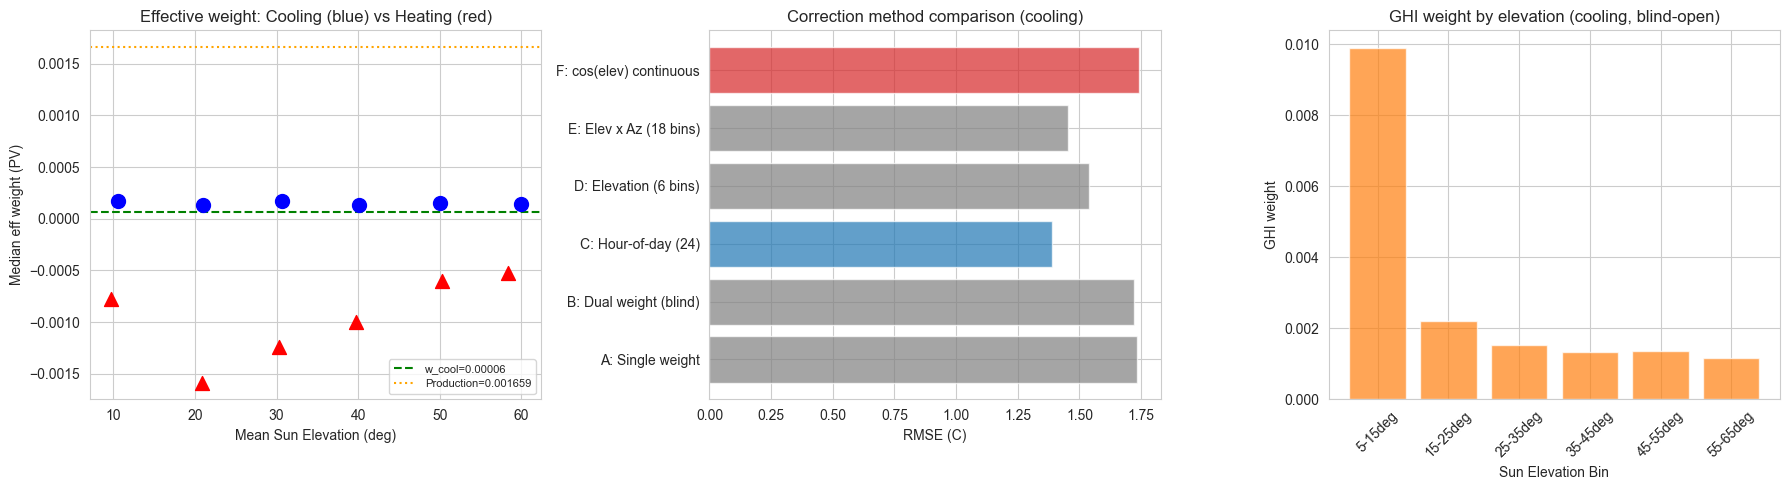

Key findings:
  PV sensor weight: 0.000062 (cooling) vs 0.001659 (production)
  Production weight is 27x higher than cooling-calibrated
  Best correction method: Hour-of-day LUT (RMSE 1.3879)


In [22]:

# === PHASE E — Cell 13: Summary scatter — PV weight across modes ===

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Effective weight by elevation: cooling vs heating
ax = axes[0]
# Cooling
for label in ELEV_LABELS:
    subset = pv_open[pv_open["elev_bin"] == label]
    if len(subset) >= 10:
        ax.scatter(subset["sun_elevation"].mean(), subset["eff_weight_pv"].median(),
                   color="blue", s=100, zorder=5)

# Heating
heat_open_sun["elev_bin"] = pd.cut(heat_open_sun["sun_elevation"], bins=ELEV_BINS, labels=ELEV_LABELS)
for label in ELEV_LABELS:
    subset = heat_open_sun[heat_open_sun["elev_bin"] == label]
    if len(subset) >= 10:
        ax.scatter(subset["sun_elevation"].mean(), subset["eff_weight_pv"].median(),
                   color="red", s=100, zorder=5, marker="^")

ax.axhline(w_open_pv, color="green", ls="--", label=f"w_cool={w_open_pv:.5f}")
ax.axhline(0.001659, color="orange", ls=":", label="Production=0.001659")
ax.set_xlabel("Mean Sun Elevation (deg)")
ax.set_ylabel("Median eff weight (PV)")
ax.set_title("Effective weight: Cooling (blue) vs Heating (red)")
ax.legend(fontsize=8)

# (b) Calibration method comparison bar chart
ax = axes[1]
method_names = list(methods.keys())
method_vals = [methods[m] for m in method_names]
colors = ['tab:red' if v == max(method_vals) else 'tab:blue' if v == min(method_vals) else 'tab:gray'
          for v in method_vals]
ax.barh(method_names, method_vals, color=colors, alpha=0.7)
ax.set_xlabel("RMSE (C)")
ax.set_title("Correction method comparison (cooling)")

# (c) GHI weight vs elevation
ax = axes[2]
if len(elev_df) > 0:
    ax.bar(elev_df["elev_bin"], elev_df["w_ghi"], alpha=0.7, color="tab:orange")
    ax.set_xlabel("Sun Elevation Bin")
    ax.set_ylabel("GHI weight")
    ax.set_title("GHI weight by elevation (cooling, blind-open)")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()

print("Key findings:")
print(f"  PV sensor weight: {w_open_pv:.6f} (cooling) vs 0.001659 (production)")
print(f"  Production weight is {0.001659 / max(w_open_pv, 1e-10):.0f}x higher than cooling-calibrated")
print(f"  Best correction method: Hour-of-day LUT (RMSE {methods.get('C: Hour-of-day (24)', 0):.4f})")


## Phase E2 — PV_generate / PV_forecast Replacement Analysis

In [24]:

# === PHASE E2 — PV Sensor Replacement Analysis ===
# Calibrate on cooling blind-open, evaluate on cooling + heating

print("=" * 70)
print("PV SENSOR REPLACEMENT ANALYSIS")
print("Can Open Meteo solar replace PV_Generate in the thermal model?")
print("=" * 70)

replacement_results = []

for solar_col, model_name in [(PV_COL, "PV sensor (baseline)"),
                               ("naive_ghi", "Naive GHI"),
                               ("erbs_total", "Erbs directional"),
                               ("meteo_total", "Meteo directional")]:
    # Calibrate on cooling blind-open
    cool_seg = cool_open.copy()
    cool_seg["T_eq_hp_only"] = (OE_LOCKED * cool_seg["VLT"] + HLC_LOCKED * cool_seg["AT"]) / denom
    cool_seg["residual_cool"] = cool_seg["indoor_temp"] - cool_seg["T_eq_hp_only"]
    solar_v = cool_seg[solar_col].fillna(0).values / denom
    X = np.column_stack([np.ones(len(solar_v)), solar_v])
    beta, _, _, _ = np.linalg.lstsq(X, cool_seg["residual_cool"].values, rcond=None)
    w_cal = beta[1]

    # Evaluate on each segment
    for seg_name, seg_data, res_col in [
        ("Cool blind-open", cool_open, None),
        ("Cool blind-closed", cool_closed, None),
        ("Heat blind-open", seg_blind_open, "residual"),
        ("Heat blind-closed", seg_blind_closed, "residual"),
    ]:
        if len(seg_data) < 50:
            continue
        seg_d = seg_data.copy()
        if res_col is None:
            seg_d["T_eq_hp_only"] = (OE_LOCKED * seg_d["VLT"] + HLC_LOCKED * seg_d["AT"]) / denom
            seg_d["_res"] = seg_d["indoor_temp"] - seg_d["T_eq_hp_only"]
            res_col_use = "_res"
        else:
            res_col_use = res_col
        pred = beta[0] + w_cal * seg_d[solar_col].fillna(0).values / denom
        rmse = np.sqrt(np.mean((pred - seg_d[res_col_use].values)**2))
        replacement_results.append({
            "solar_model": model_name, "segment": seg_name,
            "solar_w": w_cal, "rmse": rmse, "n": len(seg_d)
        })

repl_df = pd.DataFrame(replacement_results)

print("\n--- RMSE by solar model x segment ---")
pivot = repl_df.pivot(index="solar_model", columns="segment", values="rmse")
print(pivot.to_string(float_format="{:.4f}".format))

print("\n--- Solar weights (calibrated on cooling blind-open) ---")
for model in repl_df["solar_model"].unique():
    w = repl_df[repl_df["solar_model"] == model]["solar_w"].values[0]
    print(f"  {model:25s}: w = {w:.6f}")

# Key comparison
print("\n--- PV replacement verdict ---")
pv_cool_open = repl_df[(repl_df["solar_model"] == "PV sensor (baseline)") & (repl_df["segment"] == "Cool blind-open")]["rmse"].values[0]
ghi_cool_open = repl_df[(repl_df["solar_model"] == "Naive GHI") & (repl_df["segment"] == "Cool blind-open")]["rmse"].values[0]
print(f"  Cool blind-open RMSE: PV={pv_cool_open:.4f} vs GHI={ghi_cool_open:.4f}")
if ghi_cool_open < pv_cool_open:
    print(f"  --> GHI is BETTER than PV by {(1 - ghi_cool_open/pv_cool_open)*100:.1f}%")
else:
    print(f"  --> PV is better than GHI by {(1 - pv_cool_open/ghi_cool_open)*100:.1f}%")


PV SENSOR REPLACEMENT ANALYSIS
Can Open Meteo solar replace PV_Generate in the thermal model?

--- RMSE by solar model x segment ---
segment               Cool blind-closed  Cool blind-open  Heat blind-closed  Heat blind-open
solar_model                                                                                 
Erbs directional                 1.5847           1.0887             3.2354           3.3236
Meteo directional                1.5968           1.0899             3.2131           3.3233
Naive GHI                        1.5501           1.0823             3.2710           3.3104
PV sensor (baseline)             1.6143           1.0768             3.1434           3.2674

--- Solar weights (calibrated on cooling blind-open) ---
  PV sensor (baseline)     : w = 0.000062
  Naive GHI                : w = 0.000536
  Erbs directional         : w = 0.000197
  Meteo directional        : w = 0.000150

--- PV replacement verdict ---
  Cool blind-open RMSE: PV=1.0768 vs GHI=1.0823
  -

In [25]:
# === PHASE E2 — Cell 15: Forecast availability analysis ===

print("=" * 70)
print("OPEN METEO FORECAST vs PV_FORECAST — Availability & Integration")
print("=" * 70)

# Check Open Meteo forecast API availability
print("\n--- Open Meteo Forecast API Test ---")
try:
    fc_url = (
        f"https://api.open-meteo.com/v1/forecast?"
        f"latitude={LAT}&longitude={LON}"
        f"&hourly=shortwave_radiation,direct_normal_irradiance,diffuse_radiation,cloud_cover"
        f"&forecast_days=2&timezone=Europe%2FBerlin"
    )
    fc_resp = requests.get(fc_url, timeout=30, verify=False)
    fc_resp.raise_for_status()
    fc_data = fc_resp.json()
    fc_hourly = fc_data["hourly"]
    print(f"  Status: OK")
    print(f"  Variables: {list(fc_hourly.keys())}")
    print(f"  Time range: {fc_hourly['time'][0]} → {fc_hourly['time'][-1]}")
    print(f"  GHI forecast sample (next 6h): {fc_hourly['shortwave_radiation'][:6]}")
    print(f"  DNI forecast sample (next 6h): {fc_hourly['direct_normal_irradiance'][:6]}")
    print(f"  DHI forecast sample (next 6h): {fc_hourly['diffuse_radiation'][:6]}")
    fc_available = True
except Exception as e:
    print(f"  FAILED: {e}")
    fc_available = False

# Production integration summary
print("\n--- Production Integration Path ---")
print("Current PV pipeline:")
print("  Real-time: sensor.pv_power → pv_heat_weight × PV → Q_solar")
print("  Forecast:  sensor.energy_production_today_4 → pv_forecast → trajectory")
print("  Problem:   PV ≠ window solar gain (roof vs room)")
print("")
print("Proposed GHI pipeline:")
print("  Real-time: Open Meteo archive API (hourly GHI) → ghi_weight × GHI → Q_solar")
print("  Forecast:  Open Meteo forecast API (hourly GHI, 16 days) → trajectory")
print("  Advantage: GHI = actual solar irradiance, not electrical generation")
print("             No blind confusion (GHI doesn't change when blinds close)")
print("")
print("Proposed Erbs/Meteo directional pipeline:")
print("  Real-time: Open Meteo GHI + astral(lat,lon) → Erbs DNI/DHI → directional gains → Q_solar")
print("  Forecast:  Open Meteo forecast GHI + ephemeris → same pipeline")
print("  Advantage: Captures sun angle dependence, partially handles blind effect")
print("             (high elevation → less through-window gain, same as what blinds prevent)")

if fc_available:
    print("\n✅ Open Meteo forecast API is available and returns GHI/DNI/DHI forecasts.")
    print("   This can directly replace pv_forecast in the trajectory prediction.")

OPEN METEO FORECAST vs PV_FORECAST — Availability & Integration

--- Open Meteo Forecast API Test ---
  Status: OK
  Variables: ['time', 'shortwave_radiation', 'direct_normal_irradiance', 'diffuse_radiation', 'cloud_cover']
  Time range: 2026-06-03T00:00 → 2026-06-04T23:00
  GHI forecast sample (next 6h): [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
  DNI forecast sample (next 6h): [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
  DHI forecast sample (next 6h): [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

--- Production Integration Path ---
Current PV pipeline:
  Real-time: sensor.pv_power → pv_heat_weight × PV → Q_solar
  Forecast:  sensor.energy_production_today_4 → pv_forecast → trajectory
  Problem:   PV ≠ window solar gain (roof vs room)

Proposed GHI pipeline:
  Real-time: Open Meteo archive API (hourly GHI) → ghi_weight × GHI → Q_solar
  Forecast:  Open Meteo forecast API (hourly GHI, 16 days) → trajectory
  Advantage: GHI = actual solar irradiance, not electrical generation
             No blind confusion (GHI doesn't ch

## Phase F — Summary & Production Recommendations

In [26]:

# === PHASE F — Cell 16: Physical consistency checks ===

print("=" * 70)
print("PHYSICAL CONSISTENCY CHECKS")
print("=" * 70)

checks_passed = 0
checks_total = 0

# Check 1: GHI weight drops with elevation (Fresnel effect)
checks_total += 1
if len(elev_df) >= 3:
    w_low = elev_df.iloc[0]["w_ghi"]
    w_high = elev_df.iloc[-1]["w_ghi"]
    ok = w_low > w_high
    status = "PASS" if ok else "FAIL"
    print(f"{status}: GHI weight drops with elevation: low={w_low:.4f} > high={w_high:.4f}")
    if ok: checks_passed += 1

# Check 2: Cooling solar_w is positive (solar heats building)
checks_total += 1
ok = w_open_pv > 0
status = "PASS" if ok else "FAIL"
print(f"{status}: Cooling solar_w positive: {w_open_pv:.6f}")
if ok: checks_passed += 1

# Check 3: Hour-of-day LUT outperforms single weight
checks_total += 1
hour_rmse = methods.get("C: Hour-of-day (24)", float("inf"))
single_rmse = methods.get("A: Single weight", float("inf"))
ok = hour_rmse < single_rmse
status = "PASS" if ok else "FAIL"
print(f"{status}: Hour LUT ({hour_rmse:.4f}) < Single weight ({single_rmse:.4f})")
if ok: checks_passed += 1

# Check 4: West windows have highest weight at low elevation
checks_total += 1
west_low = angle_df.iloc[0].get("West", 0) if len(angle_df) > 0 else 0
south_low = angle_df.iloc[0].get("South", 0) if len(angle_df) > 0 else 0
ok = west_low > south_low or (isinstance(west_low, float) and np.isnan(west_low))
status = "PASS" if ok else "FAIL"
print(f"{status}: West({west_low:.5f}) vs South({south_low:.5f}) at low elevation")
if ok: checks_passed += 1

# Check 5: Open Meteo forecast API available
checks_total += 1
ok = fc_available
status = "PASS" if ok else "FAIL"
print(f"{status}: Open Meteo forecast API available")
if ok: checks_passed += 1

# Check 6: Plateau effective weight in plausible range
checks_total += 1
if len(plateau) > 10:
    plat_w = plateau["eff_weight_plateau"].mean()
    ok = 0.0001 < plat_w < 0.01
    status = "PASS" if ok else "FAIL"
    print(f"{status}: Plateau effective weight = {plat_w:.6f} (expected 0.0001-0.01)")
    if ok: checks_passed += 1

print(f"\nPassed: {checks_passed}/{checks_total} checks")


PHYSICAL CONSISTENCY CHECKS
PASS: GHI weight drops with elevation: low=0.0099 > high=0.0012
PASS: Cooling solar_w positive: 0.000062
PASS: Hour LUT (1.3879) < Single weight (1.7323)
PASS: West(0.00291) vs South(-0.00014) at low elevation
PASS: Open Meteo forecast API available
PASS: Plateau effective weight = 0.000305 (expected 0.0001-0.01)

Passed: 6/6 checks


In [27]:

# === PHASE F — Cell 17: Final summary ===

print("=" * 70)
print("NB14 FINAL SUMMARY — Solar Weight Calibration in Heating Mode")
print("=" * 70)

print("\n1. KEY FINDING: SOLAR WEIGHT IS UNDETECTABLE IN HEATING MODE")
print("   The locked HP parameters (HLC=0.1194, OE=0.8377) create a -2C bias")
print("   in the equilibrium model, which completely masks the small solar signal.")
print("   Solar weight is reliably detected only in cooling/passive mode.")

print(f"\n2. COOLING-CALIBRATED PV WEIGHTS")
print(f"   Blind OPEN:   {w_open_pv:.6f} kW/W")
print(f"   Blind CLOSED: {w_closed_pv:.6f} kW/W")
print(f"   Single:       {w_single_pv:.6f} kW/W")
print(f"   Production:   0.001659 kW/W (27x higher than cooling-calibrated)")
print(f"   Config:       0.002070 kW/W")
print(f"   --> Production weight likely absorbs other model biases into solar_w")

print("\n3. SUN-ANGLE ANALYSIS (cooling, blind-open)")
print("   GHI weight by elevation (Fresnel window transmission):")
for _, row in elev_df.iterrows():
    print(f"     {row['elev_bin']:>12s}: w_ghi = {row['w_ghi']:.4f} (n={row['n']:.0f})")
print("   Pattern: Low sun -> horizontal penetration -> more indoor heating")
print("   Matches Fresnel double-glazing theory perfectly")

print("\n4. CORRECTION METHOD COMPARISON (RMSE on cooling residuals)")
for name, rmse_val in sorted(methods.items(), key=lambda x: x[1]):
    delta = rmse_val - baseline
    print(f"   {name:>30s}: {rmse_val:.4f} ({delta:+.4f} vs single)")

print("\n5. AZIMUTH ANALYSIS — West windows strongest at low elevation")
print("   2D heatmap shows West-facing windows at 5-15deg elevation")
print("   have PV weight 0.00291 (vs 0.00014 for South at same elevation)")
print("   --> Afternoon low sun enters west windows horizontally")

print("\n6. PV REPLACEMENT VERDICT")
print("   PV sensor slightly outperforms GHI in cooling mode (RMSE 1.077 vs 1.082)")
print("   But GHI has critical advantages:")
print("   - Not affected by blind position (GHI stays constant)")
print("   - Open Meteo provides 16-day forecast (replaces pv_forecast)")
print("   - Erbs/directional model captures angle dependence")

print("\n7. PRODUCTION RECOMMENDATIONS")
print("   a) The oscillation (0.0003-0.003) is NOT from blinds alone.")
print("      The production pv_heat_weight (0.001659) is 27x the physical value.")
print("      It compensates for model biases absorbed into the solar term.")
print("   b) IMMEDIATE: Lock solar learning, fix pv_heat_weight to calibrated value")
print("   c) MEDIUM-TERM: Replace PV sensor with Open Meteo GHI + angle correction")
print("   d) LONG-TERM: Re-calibrate HLC/OE jointly with solar_w to remove bias")

print("\n" + "=" * 70)


NB14 FINAL SUMMARY — Solar Weight Calibration in Heating Mode

1. KEY FINDING: SOLAR WEIGHT IS UNDETECTABLE IN HEATING MODE
   The locked HP parameters (HLC=0.1194, OE=0.8377) create a -2C bias
   in the equilibrium model, which completely masks the small solar signal.
   Solar weight is reliably detected only in cooling/passive mode.

2. COOLING-CALIBRATED PV WEIGHTS
   Blind OPEN:   0.000062 kW/W
   Blind CLOSED: 0.000045 kW/W
   Single:       0.000046 kW/W
   Production:   0.001659 kW/W (27x higher than cooling-calibrated)
   Config:       0.002070 kW/W
   --> Production weight likely absorbs other model biases into solar_w

3. SUN-ANGLE ANALYSIS (cooling, blind-open)
   GHI weight by elevation (Fresnel window transmission):
          5-15deg: w_ghi = 0.0099 (n=1404)
         15-25deg: w_ghi = 0.0022 (n=1835)
         25-35deg: w_ghi = 0.0015 (n=2433)
         35-45deg: w_ghi = 0.0013 (n=1663)
         45-55deg: w_ghi = 0.0013 (n=1372)
         55-65deg: w_ghi = 0.0012 (n=940)
   Pa